In [1]:
import pandas as pd
import numpy as np

# For visualization later
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
import os

# Add src folder to path
sys.path.append(os.path.abspath("../src"))

from data_loader import generate_synthetic_data

In [3]:
df = generate_synthetic_data(num_days=180)

df.head()

,Date,Category,Amount,Type,Payment_Method
0,2025-10-22 08:17:20.645054,Shopping,1360.0,Expense,Cash
1,2025-10-22 08:17:20.645054,Travel,121.0,Expense,UPI
2,2025-10-22 08:17:20.645054,Bills,621.0,Expense,Cash
3,2025-10-23 08:17:20.645054,Travel,252.0,Expense,UPI
4,2025-10-23 08:17:20.645054,Shopping,630.0,Expense,Card


In [4]:
os.makedirs("../data", exist_ok=True)
df.to_csv("../data/raw_expenses.csv", index=False)

print("✅ Data saved successfully!")

✅ Data saved successfully!


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            306 non-null    datetime64[us]
 1   Category        306 non-null    str           
 2   Amount          306 non-null    float64       
 3   Type            306 non-null    str           
 4   Payment_Method  306 non-null    str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 17.4 KB


In [6]:
df.describe()

,Date,Amount
count,306,306.000000
mean,2026-01-20 15:11:27.703877,1860.176471
min,2025-10-22 08:17:20.645054,50.000000
25%,2025-12-05 08:17:20.645054,264.000000
50%,2026-01-23 20:17:20.645054,656.500000
75%,2026-03-08 02:17:20.645054,1452.000000
max,2026-04-19 08:17:20.645054,55939.000000
std,NaN,6306.421419


In [7]:
print("Categories:", df["Category"].unique())
print("Types:", df["Type"].unique())
print("Payment Methods:", df["Payment_Method"].unique())

Categories: <ArrowStringArray>
['Shopping', 'Travel', 'Bills', 'Entertainment', 'Food', 'Salary', 'Rent']
Length: 7, dtype: str
Types: <ArrowStringArray>
['Expense', 'Income']
Length: 2, dtype: str
Payment Methods: <ArrowStringArray>
['Cash', 'UPI', 'Card', 'Bank Transfer']
Length: 4, dtype: str


## 📌 Observations from Raw Data

- Dataset contains both Income and Expense transactions
- Salary appears monthly (1st of month)
- Rent appears once monthly
- Weekend expenses are slightly higher
- Categories are well distributed

In [8]:
cleaned_df = pd.read_csv("../data/cleaned_expenses.csv")

cleaned_df.head()

,Date,Category,Amount,Type,Payment_Method,Year,Month,Month_Name,Day,Weekday,Is_Weekend,Is_Expense,YearMonth
0,2025-10-22 08:17:20.645054,Shopping,1360.0,Expense,Cash,2025,10,October,22,Wednesday,False,True,2025-10
1,2025-10-22 08:17:20.645054,Travel,121.0,Expense,Upi,2025,10,October,22,Wednesday,False,True,2025-10
2,2025-10-22 08:17:20.645054,Bills,621.0,Expense,Cash,2025,10,October,22,Wednesday,False,True,2025-10
3,2025-10-23 08:17:20.645054,Travel,252.0,Expense,Upi,2025,10,October,23,Thursday,False,True,2025-10
4,2025-10-23 08:17:20.645054,Shopping,630.0,Expense,Card,2025,10,October,23,Thursday,False,True,2025-10


In [9]:
import pandas as pd

df = pd.read_csv("../data/cleaned_expenses.csv")
df.head()

,Date,Category,Amount,Type,Payment_Method,Year,Month,Month_Name,Day,Weekday,Is_Weekend,Is_Expense,YearMonth
0,2025-10-22 08:17:20.645054,Shopping,1360.0,Expense,Cash,2025,10,October,22,Wednesday,False,True,2025-10
1,2025-10-22 08:17:20.645054,Travel,121.0,Expense,Upi,2025,10,October,22,Wednesday,False,True,2025-10
2,2025-10-22 08:17:20.645054,Bills,621.0,Expense,Cash,2025,10,October,22,Wednesday,False,True,2025-10
3,2025-10-23 08:17:20.645054,Travel,252.0,Expense,Upi,2025,10,October,23,Thursday,False,True,2025-10
4,2025-10-23 08:17:20.645054,Shopping,630.0,Expense,Card,2025,10,October,23,Thursday,False,True,2025-10


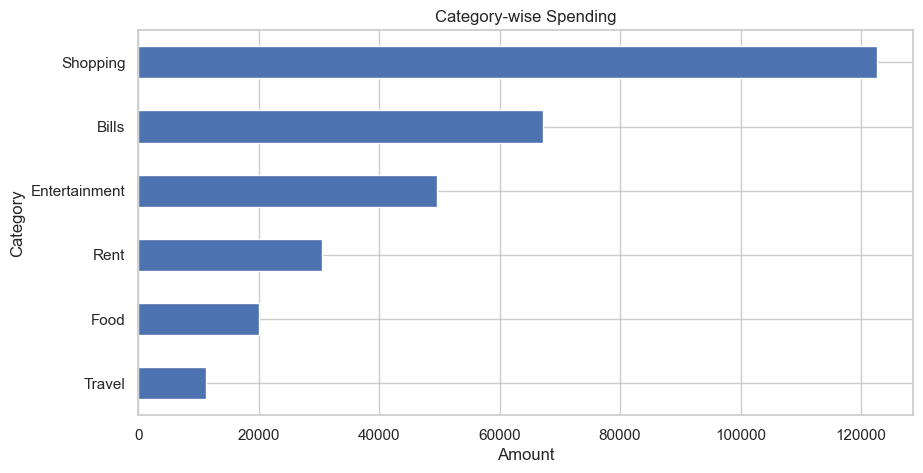

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

category_data = df[df["Type"] == "Expense"].groupby("Category")["Amount"].sum().sort_values()

plt.figure(figsize=(10,5))
category_data.plot(kind="barh")
plt.title("Category-wise Spending")
plt.xlabel("Amount")
plt.ylabel("Category")
plt.show()

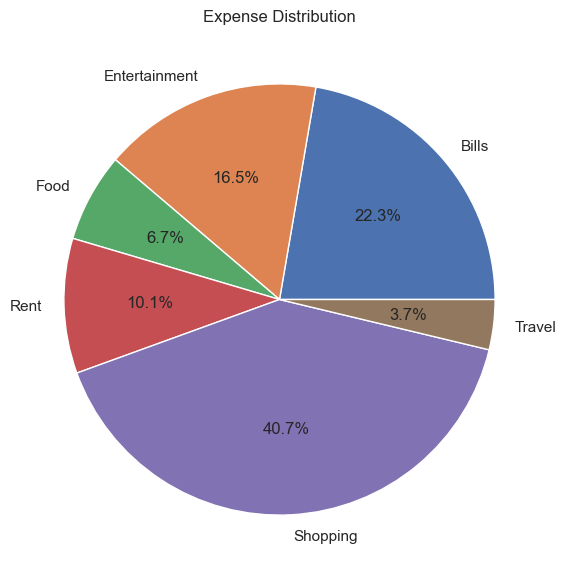

In [11]:
expense_data = df[df["Type"] == "Expense"].groupby("Category")["Amount"].sum()

plt.figure(figsize=(7,7))
plt.pie(expense_data, labels=expense_data.index, autopct="%1.1f%%")
plt.title("Expense Distribution")
plt.show()

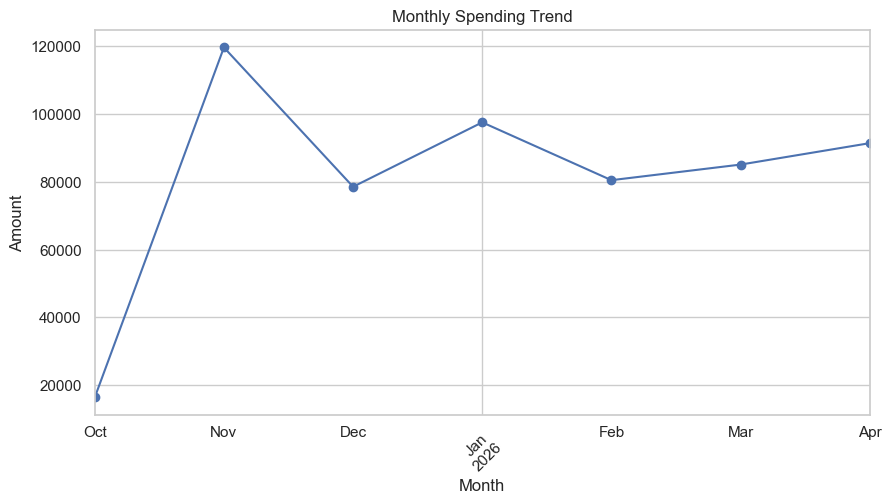

In [12]:
df["Date"] = pd.to_datetime(df["Date"])
df["YearMonth"] = df["Date"].dt.to_period("M")

monthly = df.groupby("YearMonth")["Amount"].sum()

plt.figure(figsize=(10,5))
monthly.plot(marker="o")
plt.title("Monthly Spending Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.show()

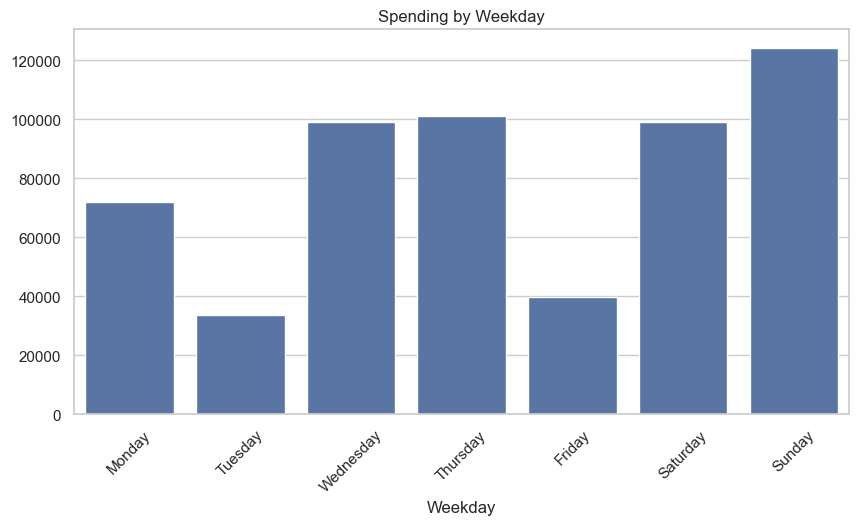

In [13]:
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

weekday_data = df.groupby("Weekday")["Amount"].sum().reindex(order)

plt.figure(figsize=(10,5))
sns.barplot(x=weekday_data.index, y=weekday_data.values)
plt.title("Spending by Weekday")
plt.xticks(rotation=45)
plt.show()

## 📊 Key Insights

- Highest spending occurs in Shopping / Rent categories
- Weekend spending is higher than weekdays
- Expenses increase gradually over time
- Income spikes at the beginning of each month

09:09:47 - cmdstanpy - INFO - Chain [1] start processing
09:09:47 - cmdstanpy - INFO - Chain [1] done processing


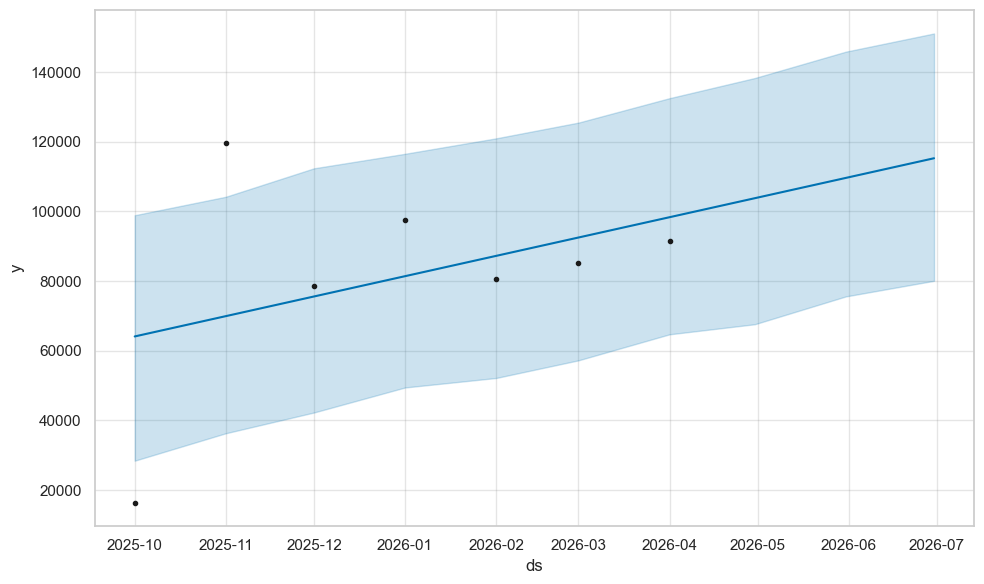

In [15]:
from prophet import Prophet

# Prepare data
monthly = df.groupby(df["Date"].dt.to_period("M"))["Amount"].sum().reset_index()
monthly.columns = ["ds", "y"]
monthly["ds"] = monthly["ds"].astype(str)
monthly["ds"] = pd.to_datetime(monthly["ds"])

model = Prophet()
model.fit(monthly)

future = model.make_future_dataframe(periods=3, freq="ME")
forecast = model.predict(future)

model.plot(forecast)
plt.show()